[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/czh4ng/DASNet-workshop/blob/main/notebooks/lab2d_dasnet_inference.ipynb)

# Lab 2d: DASNet Inference

In this lab, you will learn how to:
- Load SeaFOAM DAS tiles used in the workshop;
- Run DASNet for detection, classification, masks, and arrival-oriented picks;
- Inspect saved JSON and quicklook figures;
- Optionally run the same pipeline through predict.py from the shell.

**References:**
- Zhang, C., et al. (2026). "A deep learning framework for marine acoustic and seismic monitoring with distributed acoustic sensing." [arXiv:2603.14844](https://arxiv.org/abs/2603.14844).
- Romanowicz, B., et al. (2023). "SeaFOAM: A year‐long DAS deployment in Monterey Bay, California." *SRL*, 94(5), 2348-2359.

---


## Setup


In [1]:
import os
import subprocess

REPO_URL = "https://github.com/czh4ng/DASNet-workshop.git"
WORK_DIR = os.path.abspath(os.path.join(os.getcwd(), "DASNet-workshop"))

if not os.path.isdir(WORK_DIR):
    subprocess.run(["git", "clone", REPO_URL, WORK_DIR], check=True)
    print("Cloned to:", WORK_DIR)
else:
    print("Directory already exists:", WORK_DIR)

os.chdir(WORK_DIR)
print("cwd:", os.getcwd())


Cloned to: /content/DASNet-workshop
cwd: /content/DASNet-workshop


In [2]:
%pip install -q -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 72.7 MB/s eta 0:00:00


In [7]:
import csv
import json
import subprocess
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import urllib.request
from IPython.display import Image, display
from tqdm.auto import tqdm

%matplotlib inline

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DEEP_START = 0
DS_PLOT = 2


def plot_das(ax, arr_ch_by_time, dt_s=None, **kwargs):
    arr = np.asarray(arr_ch_by_time)
    extent = None
    if dt_s is not None:
        nt = arr.shape[1]
        extent = [0, nt * float(dt_s), arr.shape[0], 0]
    ax.imshow(
        arr[::DS_PLOT, ::DS_PLOT],
        aspect="auto",
        interpolation="bilinear",
        extent=extent,
        **kwargs,
    )


def _to_numpy_pred(d):
    return {k: (v.detach().cpu().numpy() if torch.is_tensor(v) else v) for k, v in d.items()}


Device: cpu


## 1. Load DAS Data

We use continuous DAS data from **SeaFOAM** in Monterey Bay, California (Romanowicz et al., 2023). **DASNet** was trained on SeaFOAM. The deployment uses a ~52 km fiber with 5.2 m channel spacing at 200 Hz sampling.

Shallow parts of the cable are dominated by cultural and sea-surface noise, so we focus on the **deep-water** section (channel index > 7400).

Each workshop tile is an HDF5 file containing a 2D array of shape (nx, nt) — channels by time — plus metadata for the sample interval.


In [8]:
import gcsfs

GCS_PREFIX = "workshop_dasdata/monterey_bay"
LOCAL_DATA_DIR = Path(WORK_DIR) / "data"
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

fs = gcsfs.GCSFileSystem(token="anon")
h5_gcs = sorted(f for f in fs.ls(GCS_PREFIX) if str(f).endswith(".h5"))
print(len(h5_gcs), "H5 files under", GCS_PREFIX)

for gcs_path in tqdm(h5_gcs, desc="Download", unit="file"):
    local_path = LOCAL_DATA_DIR / Path(gcs_path).name
    if not local_path.exists():
        with fs.open(gcs_path, "rb") as src, open(local_path, "wb") as dst:
            dst.write(src.read())

h5_local = sorted(LOCAL_DATA_DIR.glob("*.h5"))
h5_paths = [str(p.resolve()) for p in h5_local]
print("Local:", len(h5_paths), "→", LOCAL_DATA_DIR)

FILE_INDEX = 2  # 0-based index into h5_paths (plots, Run DASNet, Check output)
if not h5_paths:
    raise FileNotFoundError("No .h5 files under " + str(LOCAL_DATA_DIR))
if FILE_INDEX < 0 or FILE_INDEX >= len(h5_paths):
    raise IndexError(f"FILE_INDEX={FILE_INDEX} valid range is 0..{len(h5_paths) - 1}")
SELECTED_H5 = h5_paths[FILE_INDEX]

with h5py.File(SELECTED_H5, "r") as fp:
    d = fp["data"]
    raw = d[:]
    dt_s = float(d.attrs["dt_s"])

nx_full, nt = raw.shape
deep = raw[DEEP_START:, :].astype(np.float32)
print(Path(SELECTED_H5).name, "| full (nx, nt) =", (nx_full, nt), "| dt_s =", dt_s, "| deep nx =", deep.shape[0])


8 H5 files under workshop_dasdata/monterey_bay


Download:   0%|          | 0/8 [00:00<?, ?file/s]

Local: 8 → /content/DASNet-workshop/data
MBARI_GL20m_OCP5m_FS200Hz_2022-08-23T000258Z.h5 | full (nx, nt) = (2845, 12000) | dt_s = 0.004999876022338867 | deep nx = 2845


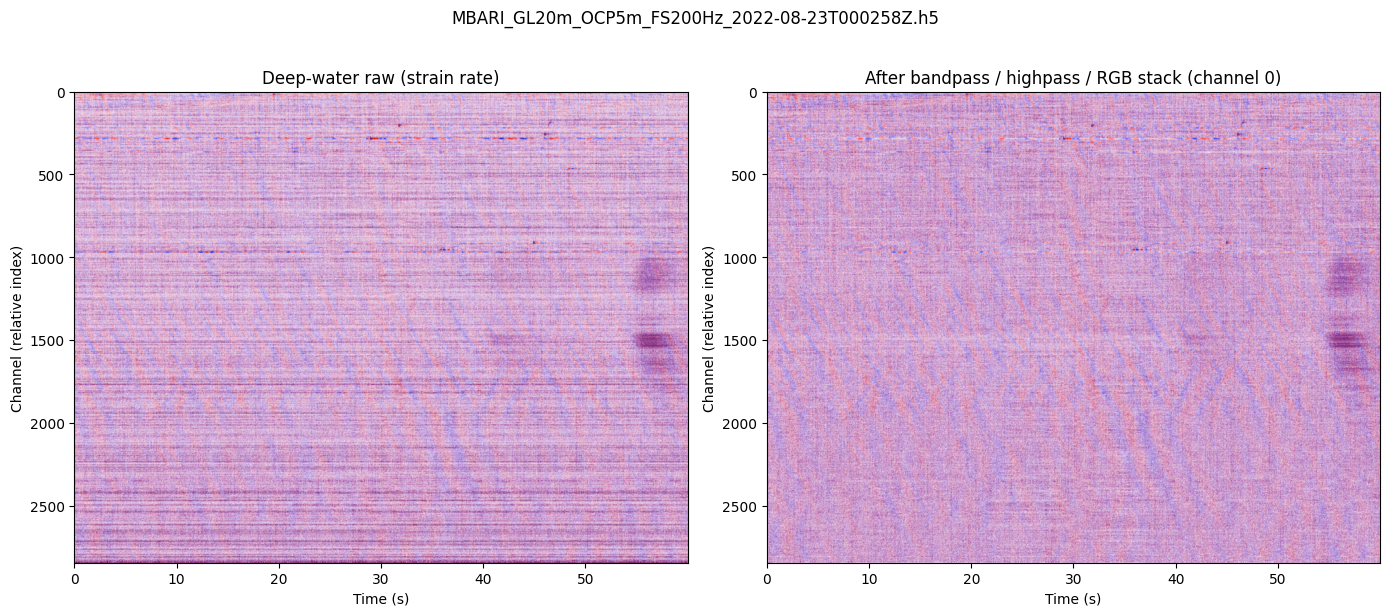

In [9]:
from dasnet.data.das import preprocess_data_rgb

vmax = 2 * float(np.percentile(np.abs(deep), 95))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_das(axes[0], deep, dt_s=dt_s, cmap="seismic", vmin=-vmax, vmax=vmax)
axes[0].set_title("Deep-water raw (strain rate)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Channel (relative index)")

rgb, _ = preprocess_data_rgb(
    SELECTED_H5,
    channel_range=(DEEP_START, None),
    data_key="data",
    data_is_strain_rate=True,
    storage_backend="local",
)
band_ch0 = rgb[:, :, 0]
vb = 2 * float(np.percentile(np.abs(band_ch0), 95))
plot_das(axes[1], band_ch0, dt_s=dt_s, cmap="seismic", vmin=-vb, vmax=vb)
axes[1].set_title("After bandpass / highpass / RGB stack (channel 0)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Channel (relative index)")

fig.suptitle(Path(SELECTED_H5).name, y=1.02)
plt.tight_layout()
plt.show()


## 2. Run DASNet

DASNet outputs a class, confidence, box, and soft mask per detection; peaks along the mask summarize arrivals where applicable. The next cell downloads the workshop checkpoint, runs the **selected** tile (FILE_INDEX above) through the model, and saves JSON plus a figure under pred_notebook/.


In [10]:
CKPT_URL = "https://github.com/czh4ng/DASNet-workshop/releases/download/v0.1.1/checkpoint.pth"
CKPT_PATH = Path(WORK_DIR) / "checkpoint.pth"
if not CKPT_PATH.exists():
    urllib.request.urlretrieve(CKPT_URL, CKPT_PATH)

from lab2d_inference_helpers import (
    build_dasnet_model,
    default_device,
    extract_peaks_for_instances,
    filter_by_score,
    forward_raw,
    load_checkpoint,
    make_infer_dataloader,
    plot_das_predictions,
    postprocess_batch,
    save_predictions_json,
)

RESIZE_SCALE = 0.5
MIN_PROB = 0.5

device = default_device()
model = build_dasnet_model()
load_checkpoint(model, str(CKPT_PATH), device)

loader, _ = make_infer_dataloader(
    [SELECTED_H5],
    batch_size=1,
    num_workers=0,
    resize_scale=RESIZE_SCALE,
    channel_range=(DEEP_START, None),
    storage_backend="local",
)
images, names = next(iter(loader))

raw_outputs = forward_raw(model, list(images), device)
_, processed = postprocess_batch(names, raw_outputs)
p0 = processed[0]
selected = filter_by_score(p0, MIN_PROB)
peak_points_list, peak_scores_list = extract_peaks_for_instances(selected)

RESULT_DIR = Path(WORK_DIR) / "pred_notebook"
FIG_DIR = RESULT_DIR / "figures_dasnet"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

fn0 = names[0]
save_predictions_json(
    fn0,
    _to_numpy_pred(selected),
    peak_points_list,
    peak_scores_list,
    str(RESULT_DIR),
    resize_scale=RESIZE_SCALE,
)
fig_path = FIG_DIR / (Path(fn0).stem + ".jpg")
plot_das_predictions(
    images[0].cpu().numpy(),
    _to_numpy_pred(selected),
    str(fig_path),
    score_threshold=MIN_PROB,
)

print("Instances kept:", len(selected["scores"]), "| JSON + figure →", RESULT_DIR)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 68.4MB/s]


Instances kept: 2 | JSON + figure → /content/DASNet-workshop/pred_notebook


## 3. Check output

Open the quicklook figure and JSON for the **same** tile as FILE_INDEX / Run DASNet. Each instance stores the box and (when present) pick coordinates in **full-resolution** channel/time units after undoing the resize, together with class id, score, and per-pick mask scores.


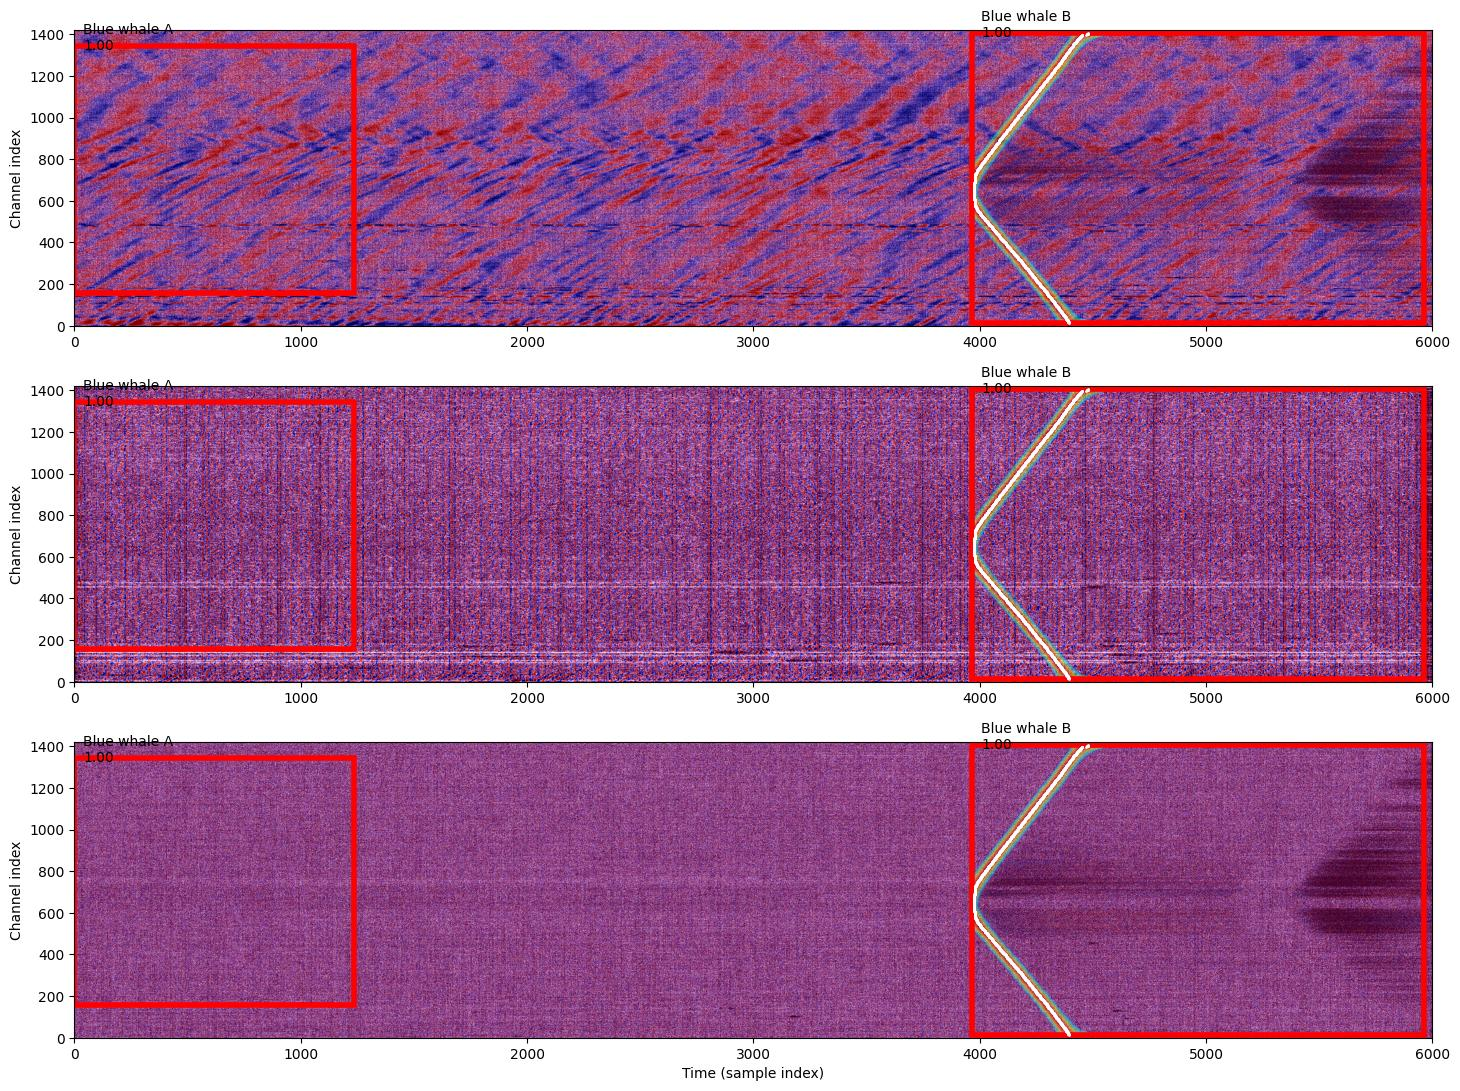

{
  "file_name": "MBARI_GL20m_OCP5m_FS200Hz_2022-08-23T000258Z.h5",
  "resize_scale": 0.5,
  "instances": [
    {
      "box": [
        24.6925048828125,
        7930.4248046875,
        2815.31689453125,
        11928.7333984375
      ],
      "score": 0.9995535016059875,
      "label": 2,
      "label_name": "Blue whale B",
      "picks": [
        [
          30.0,
          8786.0
        ],
        [
          32.0,
          8786.0
        ],
        [
          34.0,
          8786.0
        ],
        [
          36.0,
          8784.0
        ],
        [
          38.0,
          8784.0
        ],
        "... (1390 total)"
      ],
      "pick_scores": [
        0.5111781358718872,
        0.5673083662986755,
        0.6194015145301819,
        0.6665241122245789,
        0.7080281376838684,
        "... (1390 total)"
      ]
    },
    {
      "box": [
        310.2237548828125,
        0.0,
        2688.74560546875,
        2470.9697265625
      ],
      "score": 0.998852

In [11]:
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    print("No figure at", fig_path)

json_path = RESULT_DIR / (Path(fn0).stem + ".json")
with open(json_path) as f:
    payload = json.load(f)

view = json.loads(json.dumps(payload))
for inst in view.get("instances", []):
    for key in ("picks", "pick_scores"):
        if key in inst and len(inst[key]) > 5:
            n = len(inst[key])
            inst[key] = inst[key][:5] + [f"... ({n} total)"]

print(json.dumps(view, indent=2))


## Optional: predict.py from the command line

The same end-to-end inference is available as a script. The example writes to pred_cli/ so it does not overwrite the notebook run. Set **CLI_ALL_TILES** to True in the next cell to pass every downloaded path; otherwise only the selected tile (FILE_INDEX) is listed.


In [12]:
pred_cli = Path(WORK_DIR) / "pred_cli"
pred_cli.mkdir(parents=True, exist_ok=True)
csv_path = pred_cli / "data_list.csv"

CLI_ALL_TILES = False  # True: all downloaded .h5; False: only SELECTED_H5
paths_for_cli = h5_paths if CLI_ALL_TILES else [SELECTED_H5]

with open(csv_path, "w", newline="") as fp:
    w = csv.writer(fp)
    w.writerow(["path"])
    for p in paths_for_cli:
        w.writerow([p])

predict_py = Path(WORK_DIR) / "predict.py"
base = [
    str(predict_py),
    "--model",
    "dasnet",
    "--resume",
    str(CKPT_PATH),
    "--data_list",
    str(csv_path),
    "--batch_size",
    "1",
    "--min_prob",
    str(MIN_PROB),
    "--result_path",
    str(pred_cli),
    "--plot_figure",
    "--workers",
    "0",
]
if DEVICE.type == "cpu":
    cmd = ["python"] + base + ["--device", "cpu"]
else:
    cmd = ["python"] + base

print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, cwd=str(WORK_DIR), capture_output=True, text=True)
print(proc.stdout)
if proc.stderr:
    print(proc.stderr)
proc.check_returncode()

# Show JSON for the selected tile when possible
cli_json = pred_cli / (Path(SELECTED_H5).stem + ".json")
if not cli_json.exists():
    found = sorted(pred_cli.glob("*.json"))
    cli_json = found[0] if found else None
if cli_json and cli_json.exists():
    with open(cli_json) as f:
        ex = json.load(f)
    for inst in ex.get("instances", []):
        for key in ("picks", "pick_scores"):
            if key in inst and len(inst[key]) > 5:
                n = len(inst[key])
                inst[key] = inst[key][:5] + [f"... ({n} total)"]
    print("CLI JSON:", cli_json.name)
    print(json.dumps(ex, indent=2))
else:
    print("No JSON files in", pred_cli)


Running: python /content/DASNet-workshop/predict.py --model dasnet --resume /content/DASNet-workshop/checkpoint.pth --data_list /content/DASNet-workshop/pred_cli/data_list.csv --batch_size 1 --min_prob 0.5 --result_path /content/DASNet-workshop/pred_cli --plot_figure --workers 0 --device cpu
Not using distributed mode
Namespace(model='dasnet', resume='/content/DASNet-workshop/checkpoint.pth', device='cpu', batch_size=1, workers=0, amp=False, distributed=False, world_size=1, dist_url='env://', data_list='/content/DASNet-workshop/pred_cli/data_list.csv', object='default', key_path=None, result_path='/content/DASNet-workshop/pred_cli', min_prob=0.5, plot_figure=True, skip_existing=False, use_deterministic_algorithms=False)
Total file number from list: 1
Loading checkpoint: /content/DASNet-workshop/checkpoint.pth


Predicting: 100%|██████████| 1/1 [01:45<00:00, 105.58s/it]

CLI JSON: MBARI_GL20m_OCP5m_FS200Hz_2022-08-23T000258Z.json
{
  "file_name": "MBARI_GL20m_OCP5m_FS200Hz_2022-08-23T00

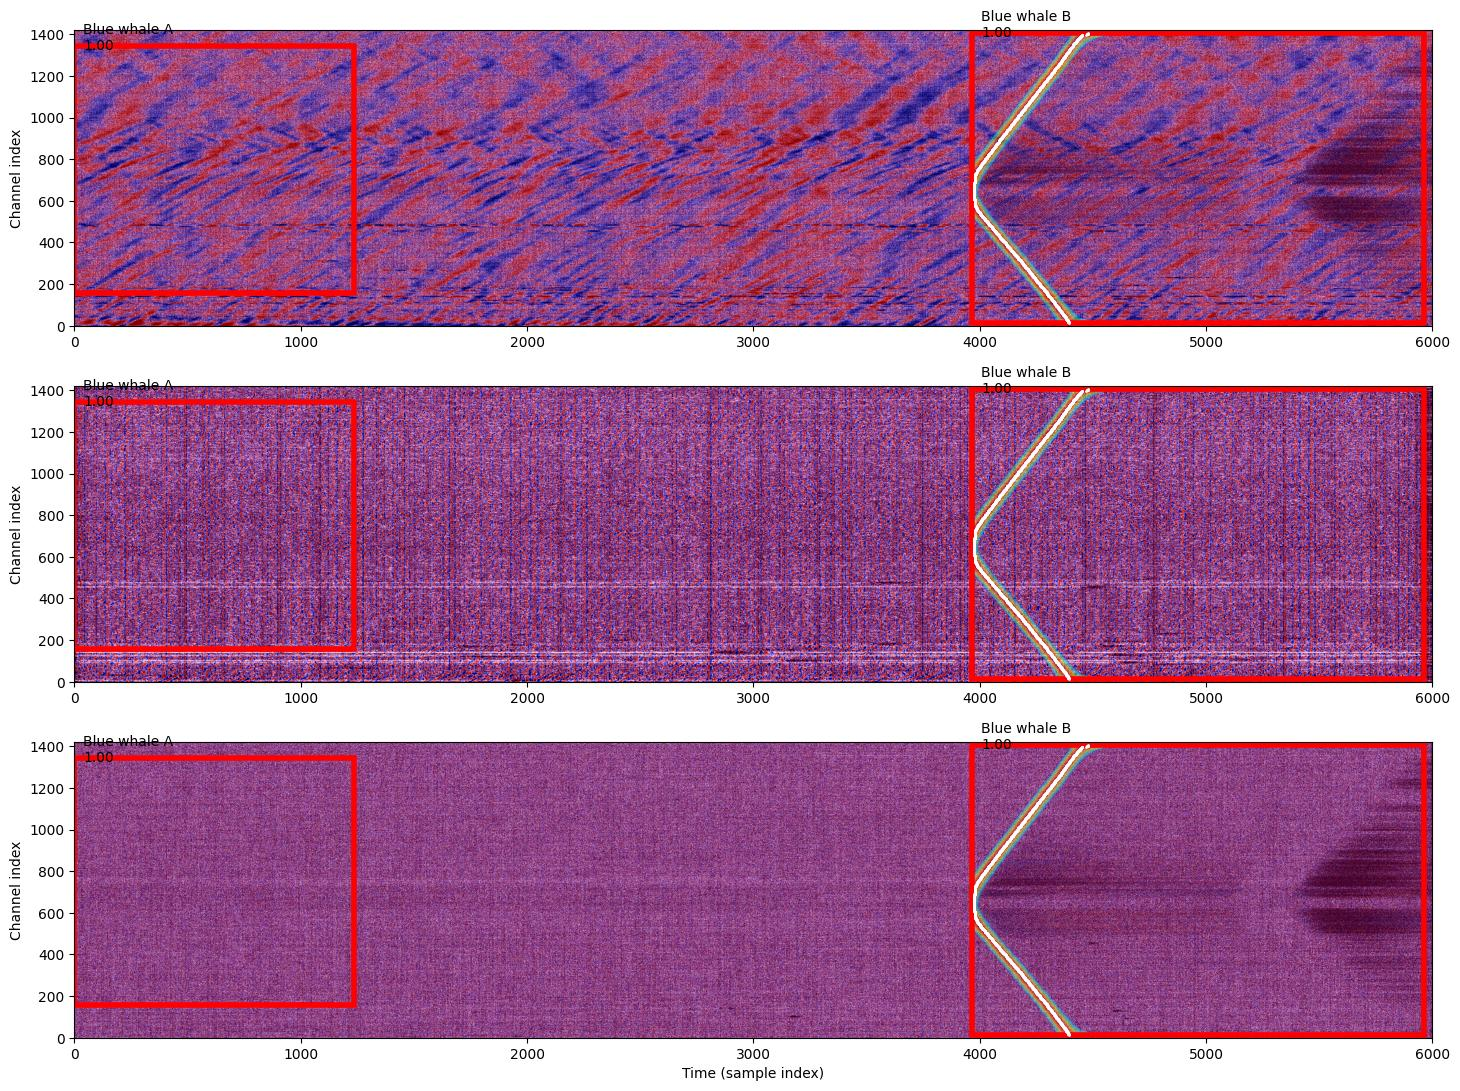

/content/DASNet-workshop/pred_cli/figures_dasnet/MBARI_GL20m_OCP5m_FS200Hz_2022-08-23T000258Z.h5.jpg


In [13]:
pred_cli = Path(WORK_DIR) / "pred_cli"
cli_fig_dir = pred_cli / "figures_dasnet"
cli_fig = cli_fig_dir / (Path(SELECTED_H5).name + ".jpg")

if cli_fig.exists():
    display(Image(filename=str(cli_fig)))
    print(cli_fig.resolve())
else:
    print("Not found:", cli_fig.resolve())
    others = sorted(cli_fig_dir.glob("*.jpg")) if cli_fig_dir.is_dir() else []
    if others:
        print("Available:", len(others), "figures; showing first:", others[0].name)
        display(Image(filename=str(others[0])))
